In [1]:
import pandas as pd
from google.colab import files

uploaded = files.upload()


Saving iris_.csv to iris_.csv


In [3]:
df = pd.read_csv("iris_.csv")

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,NaN,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


**Check the dataset**

In [4]:
print("Number of rows and columns:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Number of rows and columns:
(150, 5)

Column names:
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

Data types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Missing values:
sepal_length    0
sepal_width     0
petal_length    1
petal_width     0
species         0
dtype: int64


**Check the species**

In [5]:
print(df["species"].value_counts())

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


**Find the missing row**

In [6]:
df[df["petal_length"].isnull()]

print("Number of missing values before cleaning:")
print(df.isnull().sum())

Number of missing values before cleaning:
sepal_length    0
sepal_width     0
petal_length    1
petal_width     0
species         0
dtype: int64


**Clean the dataset**

In [7]:
df = df.dropna(subset=["petal_length"])

print("Dataset shape after cleaning:")
print(df.shape)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Dataset shape after cleaning:
(149, 5)

Missing values after cleaning:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


**Check the numerical data**

In [8]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,149.000000,149.000000,149.000000,149.000000
mean,5.848322,3.054362,3.773826,1.206040
std,0.828594,0.435810,1.760543,0.760354
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [9]:
df[df["petal_length"].isnull()]

,sepal_length,sepal_width,petal_length,petal_width,species


In [10]:
df = df.dropna(subset=["petal_length"])

In [11]:
print(df.shape)
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
df.describe()

(149, 5)
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
Duplicate rows: 1


,sepal_length,sepal_width,petal_length,petal_width
count,149.000000,149.000000,149.000000,149.000000
mean,5.848322,3.054362,3.773826,1.206040
std,0.828594,0.435810,1.760543,0.760354
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


**Investigate the duplicate**

In [12]:
df[df.duplicated(keep=False)]

,sepal_length,sepal_width,petal_length,petal_width,species
101,5.8,2.7,5.1,1.9,Iris-virginica
142,5.8,2.7,5.1,1.9,Iris-virginica


In [13]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1


**Check species after cleaning**

In [14]:
print(df["species"].value_counts())

species
Iris-versicolor    50
Iris-virginica     50
Iris-setosa        49
Name: count, dtype: int64


**Check the average petal length for each species**

In [15]:
df.groupby("species")["petal_length"].agg(
    ["count", "mean", "std", "min", "max"]
)

,count,mean,std,min,max
species,,,,,
Iris-setosa,49,1.463265,0.175231,1.0,1.9
Iris-versicolor,50,4.260000,0.469911,3.0,5.1
Iris-virginica,50,5.552000,0.551895,4.5,6.9


**Make our first visualization**

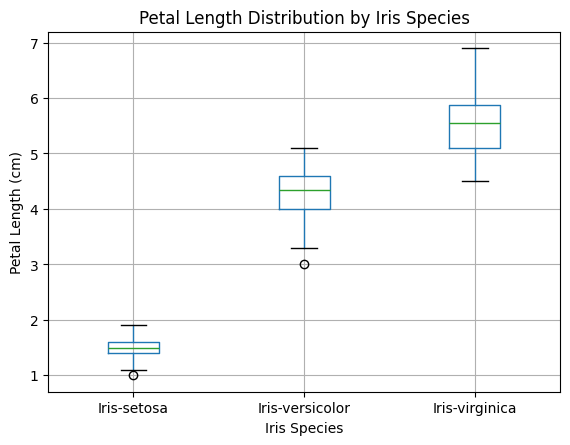

In [16]:
import matplotlib.pyplot as plt

df.boxplot(column="petal_length", by="species")

plt.title("Petal Length Distribution by Iris Species")
plt.suptitle("")
plt.xlabel("Iris Species")
plt.ylabel("Petal Length (cm)")
plt.xticks(rotation=0)
plt.show()

**Remove the duplicate**

In [17]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicate:")
print(df.shape)

print("\nSpecies counts:")
print(df["species"].value_counts())

print("\nDuplicate rows remaining:")
print(df.duplicated().sum())

Dataset shape after removing duplicate:
(148, 5)

Species counts:
species
Iris-versicolor    50
Iris-setosa        49
Iris-virginica     49
Name: count, dtype: int64

Duplicate rows remaining:
0


**Calculate final descriptive statistics**

In [18]:
df.groupby("species")["petal_length"].agg(
    ["count", "mean", "std", "min", "max"]
).round(3)

,count,mean,std,min,max
species,,,,,
Iris-setosa,49,1.463,0.175,1.0,1.9
Iris-versicolor,50,4.260,0.470,3.0,5.1
Iris-virginica,49,5.561,0.554,4.5,6.9


** Check ANOVA assumptions**

**Normality test**

In [19]:
from scipy.stats import shapiro

groups = [
    df[df["species"] == "Iris-setosa"]["petal_length"],
    df[df["species"] == "Iris-versicolor"]["petal_length"],
    df[df["species"] == "Iris-virginica"]["petal_length"]
]

for name, group in zip(
    ["Iris-setosa", "Iris-versicolor", "Iris-virginica"],
    groups
):
    statistic, p_value = shapiro(group)
    print(name)
    print("Shapiro-Wilk statistic:", round(statistic, 4))
    print("p-value:", round(p_value, 4))
    print()

Iris-setosa
Shapiro-Wilk statistic: 0.9569
p-value: 0.0706

Iris-versicolor
Shapiro-Wilk statistic: 0.966
p-value: 0.1585

Iris-virginica
Shapiro-Wilk statistic: 0.9655
p-value: 0.1597



**Test equal variances**

In [20]:
from scipy.stats import levene

statistic, p_value = levene(
    groups[0],
    groups[1],
    groups[2]
)

print("Levene's test statistic:", round(statistic, 4))
print("p-value:", round(p_value, 4))

Levene's test statistic: 18.4691
p-value: 0.0


**One more useful visualization**

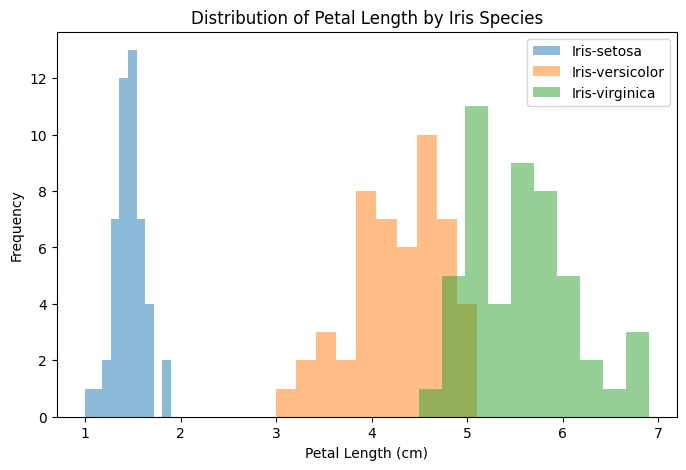

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for species in df["species"].unique():
    data = df[df["species"] == species]["petal_length"]
    plt.hist(data, alpha=0.5, label=species)

plt.xlabel("Petal Length (cm)")
plt.ylabel("Frequency")
plt.title("Distribution of Petal Length by Iris Species")
plt.legend()
plt.show()

**Perform Welch's ANOVA**

In [22]:
from scipy.stats import f_oneway

welch_result = f_oneway(
    groups[0],
    groups[1],
    groups[2],
    equal_var=False
)

print("Welch's ANOVA")
print("F-statistic:", round(welch_result.statistic, 4))
print("p-value:", welch_result.pvalue)

Welch's ANOVA
F-statistic: 1793.4542
p-value: 1.2874861435770432e-65


In [23]:
from scipy.stats import f_oneway

welch_result = f_oneway(
    groups[0],
    groups[1],
    groups[2],
    equal_var=False
)

print("Welch's ANOVA")
print("F-statistic:", round(welch_result.statistic, 4))
print("p-value:", welch_result.pvalue)

Welch's ANOVA
F-statistic: 1793.4542
p-value: 1.2874861435770432e-65


**Post-hoc analysis**

**Perform Games-Howell**

**Make the result easier to read**

In [26]:
!pip install pingouin -q

import pingouin as pg

games_howell = pg.pairwise_gameshowell(
    data=df,
    dv="petal_length",
    between="species"
)

games_howell

# Correcting the column names from 'mean(A)'/'mean(B)' to 'mean_A'/'mean_B'
games_howell[["A", "B", "mean_A", "mean_B", "diff", "pval"]]

,A,B,mean_A,mean_B,diff,pval
0,Iris-setosa,Iris-versicolor,1.463265,4.260000,-2.796735,2.930989e-14
1,Iris-setosa,Iris-virginica,1.463265,5.561224,-4.097959,0.000000e+00
2,Iris-versicolor,Iris-virginica,4.260000,5.561224,-1.301224,1.010303e-14


In [27]:
print(games_howell.columns)

Index(['A', 'B', 'mean_A', 'mean_B', 'diff', 'se', 'T', 'df', 'pval',
       'hedges'],
      dtype='object')


**Calculate 95% confidence intervals**

In [28]:
from scipy.stats import t

# Calculate 95% confidence intervals
games_howell["CI_lower"] = (
    games_howell["diff"] -
    t.ppf(0.975, games_howell["df"]) * games_howell["se"]
)

games_howell["CI_upper"] = (
    games_howell["diff"] +
    t.ppf(0.975, games_howell["df"]) * games_howell["se"]
)

# Show the important results
games_howell[
    ["A", "B", "diff", "CI_lower", "CI_upper", "pval", "hedges"]
].round(4)

,A,B,diff,CI_lower,CI_upper,pval,hedges
0,Iris-setosa,Iris-versicolor,-2.7967,-2.9387,-2.6548,0.0,-7.7949
1,Iris-setosa,Iris-virginica,-4.0980,-4.2641,-3.9319,0.0,-9.9006
2,Iris-versicolor,Iris-virginica,-1.3012,-1.5064,-1.0961,0.0,-2.5164


**Create a clean final statistical table**

In [29]:
final_results = games_howell[
    ["A", "B", "mean_A", "mean_B",
     "diff", "CI_lower", "CI_upper",
     "pval", "hedges"]
].copy()

final_results = final_results.round(4)

final_results

,A,B,mean_A,mean_B,diff,CI_lower,CI_upper,pval,hedges
0,Iris-setosa,Iris-versicolor,1.4633,4.2600,-2.7967,-2.9387,-2.6548,0.0,-7.7949
1,Iris-setosa,Iris-virginica,1.4633,5.5612,-4.0980,-4.2641,-3.9319,0.0,-9.9006
2,Iris-versicolor,Iris-virginica,4.2600,5.5612,-1.3012,-1.5064,-1.0961,0.0,-2.5164


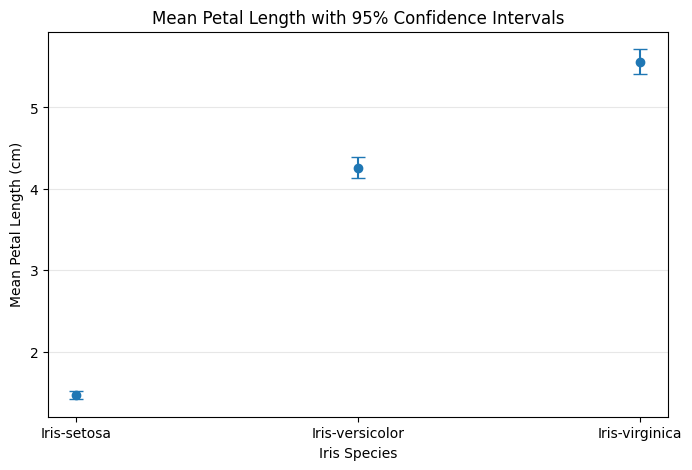

In [30]:
import matplotlib.pyplot as plt
import numpy as np

summary = df.groupby("species")["petal_length"].agg(
    ["mean", "count", "std"]
)

summary["sem"] = summary["std"] / np.sqrt(summary["count"])

# 95% confidence interval
summary["ci"] = 1.96 * summary["sem"]

plt.figure(figsize=(8, 5))

plt.errorbar(
    summary.index,
    summary["mean"],
    yerr=summary["ci"],
    fmt="o",
    capsize=5
)

plt.xlabel("Iris Species")
plt.ylabel("Mean Petal Length (cm)")
plt.title("Mean Petal Length with 95% Confidence Intervals")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()